# ZXZ Y tensor network factorization sweep

Created: 15-06-2026

Objectives:
* Build off [previous notebook](quspin_zxz_y_rdm_tensor_network_factorization.ipynb), sweep procedure over many parameters.
* Investigate accuracy close to critical point.

# Imports

In [1]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from tqdm import tqdm

In [4]:
from functools import reduce

In [5]:
import quimb.tensor as qtn
import quimb as qu

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


# Definitions
## Groundstates

In [6]:
num_sites = 16

In [7]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [8]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=num_sites):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [9]:
parameters = np.linspace(0, 1, 51)

In [10]:
hamiltonians = [
    get_hamiltoniain(t, num_sites)
    for t in parameters
]

In [11]:
energies = list()
groundstates = list()

for h in tqdm(hamiltonians):
    e, psi = h.eigsh(k=1, which='SA')

    energies.append(e)
    groundstates.append(psi)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:49<00:00,  1.03it/s]


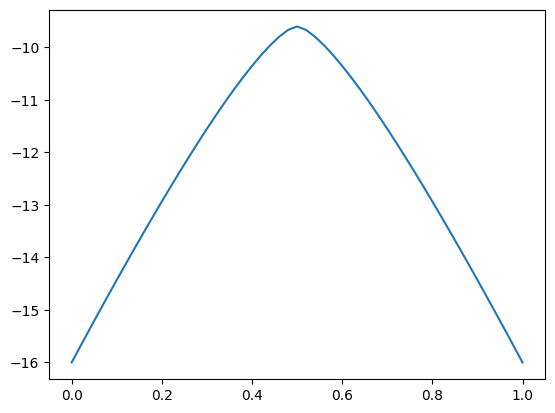

In [12]:
plt.plot(parameters, energies)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [13]:
np_X = np.array([
    [0,1],
    [1,0]
])

np_XX = np.kron(np_X, np_X)

In [14]:
qu_XX = qtn.Tensor(
    np_XX,
    inds=['k', 'b']
)

## Defect operators

In [15]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [16]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [17]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [18]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [19]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

In [20]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [21]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    return A.multiply(trace**(-0.5))

In [22]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [23]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [24]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [25]:
def loss_func(A, rho, rho_purity):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [26]:
def get_tensor_network_factorization(psi):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )

    rho_purity = np.real(np.trace(rho @ rho))

    # Hardcode warning
    rho_reshaped = rho.reshape((16, 16, 16, 16,))
    
    qt_rho = qtn.Tensor(
        data=rho_reshaped,
        inds=('kl', 'kr', 'bl', 'br')
    )

    A_left = qtn.Tensor(
        data=random_uniform_complex(
            (vertical_bond_dimension, 2**4, horiztonal_bond_dimension)
        ),
        inds=('vLV', 'kl', 'vH')
    )
    
    A_right = qtn.Tensor(
        data=random_uniform_complex(
            (horiztonal_bond_dimension, 2**4, vertical_bond_dimension)
        ),
        inds=('vH', 'kr', 'vRV')
    )

    A = qtn.TensorNetwork([A_left, A_right])

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize_basinhopping(n=100,  nhop=5)

    return A_opt, tnopt.losses, tnopt.loss_best

In [27]:
def schmidt_decompose_tensor_factorization(A_opt):
    # Left side
    A_l_opt = A_opt.tensors[0]

    tn_l = (
        A_l_opt
        &
        A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
    )
    tn_l = tn_l.contract()

    left_rho_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=['kl', 'vH'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    diff_l = (
        left_rho_decomp.contract(output_inds=tn_l.inds)
        - tn_l
    )

    left_diff = (diff_l & diff_l.conj()).contract()

    # Right side
    A_r_opt = A_opt.tensors[1]

    tn_r = (
        A_r_opt
        &
        A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
    )
    tn_r = tn_r.contract()

    right_rho_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=['kr', 'vH'],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    diff_r = (
        right_rho_decomp.contract(output_inds=tn_r.inds)
        - tn_r
    )

    right_diff = (diff_r & diff_r.conj()).contract()

    out = (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    )

    return out

In [28]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl1, kr2, bl1, br2] each with size 4 (s sites)
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kl1', 'bl1'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kr2', 'br2'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl1': 'bl1', 'bl1':'kl1'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr2', 'br2'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr2': 'br2', 'br2':'kr2'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl1', 'bl1'])

    return (left_defect_op, right_defect_op), scores

In [29]:
def get_defect_ops_and_indices_from_density_matrix(qt_rho):
    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    bra_conjugate_rho = (
        rho_purification.tensors[0]
        & rho_purification.tensors[1]
        & (rho_purification.tensors[2].conj())
    )

    (
        bra_conjugate_rho
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
            shape_map={'kl': (4, 4), 'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_rho
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2'], 'br': ['br1', 'br2']},
            shape_map={'bl': (4, 4), 'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_rho.reindex(
            {'bl1': 'bbl1', 'bl2': 'bl2', 'br1': 'br1', 'br2': 'bbr2'}
        )
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
    )

    # Ordering of indices important here.
    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        purification_diff_score
    )

    return out

In [30]:
def get_defect_ops_and_indices_from_factorized_density_matrix(qt_rho,
    left_rho_decomp, right_rho_decomp):

    bra_conjugate_left_rho_decomp = (
        left_rho_decomp.tensors[0]
        & left_rho_decomp.tensors[1]
        & (left_rho_decomp.tensors[2].conj())
    )
    
    bra_conjugate_right_rho_decomp = (
        right_rho_decomp.tensors[0]
        & right_rho_decomp.tensors[1]
        & (right_rho_decomp.tensors[2].conj())
    )

    (
        bra_conjugate_left_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2']},
            shape_map={'kl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_left_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2']},
            shape_map={'bl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2']},
            shape_map={'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'br': ['br1', 'br2']},
            shape_map={'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_left_rho_decomp.reindex({'bl1': 'bbl1', 'bl2': 'bl2'})
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & bra_conjugate_right_rho_decomp.reindex({'br1': 'br1', 'br2': 'bbr2'})
    )

    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [31]:
def get_defect_ops_and_indices_from_restricted_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())
    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlap
    )

    return out

In [32]:
def get_defect_ops_and_indices_from_restricted_purification_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )

    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [33]:
def get_restricted_psis(left_rho_decomp, right_rho_decomp, cutoff_factor=0.8):
    out = list()

    left_schmidt_vals = left_rho_decomp.tensors[1].data
    right_schmidt_vals = right_rho_decomp.tensors[1].data

    
    
    for i, sl in enumerate(left_schmidt_vals):
        if sl >= cutoff_factor*max(left_schmidt_vals):
            left_psi = left_rho_decomp.tensors[0].isel({'vLV': i})
            for j, sr in enumerate(right_schmidt_vals):
                if sr >= cutoff_factor*max(right_schmidt_vals):
                    right_psi = right_rho_decomp.tensors[0].isel({'vRV': j})

                    psi = left_psi & right_psi
                    psi_norm = (psi & psi.conj()).contract()

                    (
                        psi
                        .multiply(
                            psi_norm**(-0.5),
                            inplace=True,
                            spread_over=2
                        )
                    )

                    (
                        psi
                        .tensors[0]
                        .unfuse_(
                            unfuse_map={'kl': ['kl1', 'kl2']},
                            shape_map={'kl': (4, 4)}
                        )
                    )

                    (
                        psi
                        .tensors[1]
                        .unfuse_(
                            unfuse_map={'kr': ['kr1', 'kr2']},
                            shape_map={'kr': (4, 4)}
                        )
                    )

                    out.append([psi, sl, sr])

    return out

In [34]:
def get_restricted_psis_from_purification(qt_rho, cutoff_factor=0.65):
    out = list()

    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    schmidt_vals = rho_purification.tensors[1].data
    
    for i, schmidt_val in enumerate(schmidt_vals):
        if schmidt_val >= cutoff_factor*max(schmidt_vals):
            psi = rho_purification.tensors[0].isel({'vV': i})
            psi_norm = (psi & psi.conj()).contract()

            psi = psi_norm**(-0.5)*psi

            (
                psi
                .unfuse_(
                    unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
                    shape_map={'kl': (4, 4), 'kr': (4, 4)}
                )
            )

            out.append([psi, schmidt_val])

    return (out, purification_diff_score)

In [35]:
def get_left_right_defect_regions_schmidt_vals(qt_rho):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }
    shape_map = {k: (4,4) for k in unfuse_map.keys()}

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [36]:
def extract_time_reversal_information(psi):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )
    
    rho_purity = np.real(np.trace(rho @ rho))
    
    # Hardcode warning
    rho_reshaped = rho.reshape((16, 16, 16, 16,))
    
    qt_rho = qtn.Tensor(
        data=rho_reshaped,
        inds=('kl', 'kr', 'bl', 'br')
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho)
    )

    rho_out = get_defect_ops_and_indices_from_density_matrix(qt_rho)

    pair = get_restricted_psis_from_purification(qt_rho)
    purification_restricted_psi_pairs, purification_diff_score = pair

    purification_restricted_psi_output = list()
    for psi_0, sv in purification_restricted_psi_pairs:
        purification_restricted_psi_output.append(
            [sv, *get_defect_ops_and_indices_from_restricted_purification_state(psi_0)]
        )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(psi)

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [sl, sr, *get_defect_ops_and_indices_from_restricted_state(psi_0)]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        rho_out,
        purification_diff_score,
        purification_restricted_psi_output,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

# Sweep

In [43]:
sweep_results = list()

for psi in tqdm(groundstates):
    sweep_results.append(extract_time_reversal_information(psi))

  0%|                                                                                                             | 0/51 [00:00<?, ?it/s]WARNING:2026-06-18 14:31:16,847:jax._src.xla_bridge:791: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
  2%|█▉                                                                                                   | 1/51 [00:05<04:33,  5.47s/it]/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.

## Analyse results

### Left right rho schmidt values

In [44]:
sweep_results[0][0]

array([1.])

In [45]:
sweep_results[-1][0]

array([0.25])

In [46]:
sweep_results[-2][0]

array([2.50023145e-01, 2.31386408e-05, 2.16505631e-07, 2.16505631e-07,
       1.50605732e-10])

In [47]:
plot_schmidt_vals = list()
plot_schmidt_val_indices = list()
plot_num_schmidt_vals = list()

for i, l in enumerate(sweep_results):
    count=0
    for s in l[0]:
        if s > 0.05:
            plot_schmidt_val_indices.append(parameters[i])
            plot_schmidt_vals.append(s)

            count+=1
    plot_num_schmidt_vals.append(count)

In [48]:
plot_num_schmidt_vals

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 4,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

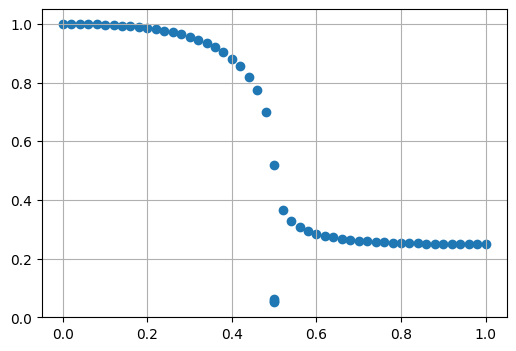

In [49]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(plot_schmidt_val_indices, plot_schmidt_vals)
ax.set_ylim(0, 1.05)
ax.grid(zorder=-1)

So the states are short range entangled, as expected.

### Purification full effective density matrix

In [50]:
purification_rho_sweep_results = [l[1] for l in sweep_results]

In [51]:
purification_rho_sweep_results[-1][0]

array([0.23163677, 0.09273728, 0.01181398, 0.01022915])

In [52]:
plot_schmidt_vals = list()
plot_schmidt_val_indices = list()
plot_num_schmidt_vals = list()

for i, l in enumerate(purification_rho_sweep_results):
    count=0
    for s in l[0]:
        if s > 0.05:
            plot_schmidt_val_indices.append(parameters[i])
            plot_schmidt_vals.append(s)

            count+=1
    plot_num_schmidt_vals.append(count)

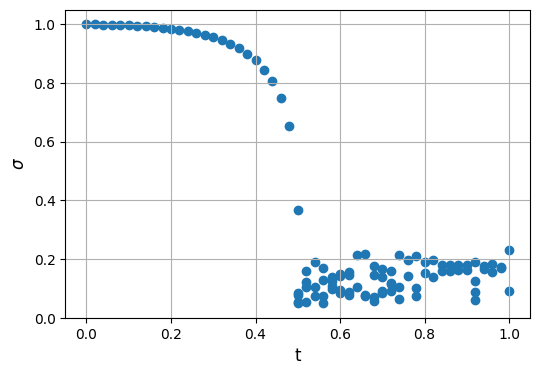

In [53]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(plot_schmidt_val_indices, plot_schmidt_vals)
ax.set_ylim(0, 1.05)
ax.grid(zorder=-1)

ax.set_ylabel('$\sigma$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

fig.savefig(
    r'figures/purified_rho_left_right_edm_schmidt_vals.png',
    bbox_inches='tight',
    dpi=200
)

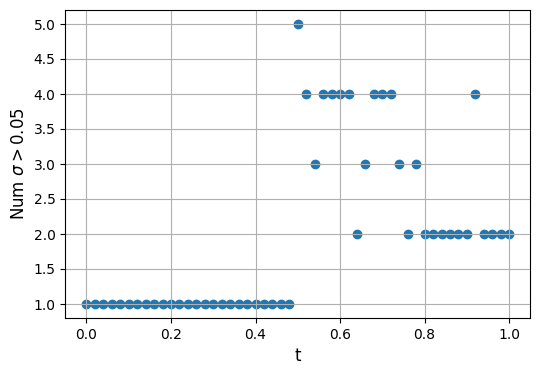

In [54]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(parameters, plot_num_schmidt_vals)
ax.grid(zorder=-1)

ax.set_ylabel('Num $\sigma > 0.05$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

fig.savefig(
    r'figures/purified_rho_num_left_right_edm_schmidt_vals.png',
    bbox_inches='tight',
    dpi=200
)

So in this case, $E$ is exhibiting long range entanglement.

In [55]:
left_defect_op_invariants = np.array([
    l[1] for l in purification_rho_sweep_results
])

right_defect_op_invariants = np.array([
    l[2] for l in purification_rho_sweep_results
])

In [56]:
(
    np.max(np.abs(np.imag(left_defect_op_invariants))),
    np.max(np.abs(np.imag(right_defect_op_invariants)))
)

(1.991279315050054e-09, 2.7602365532120032e-09)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


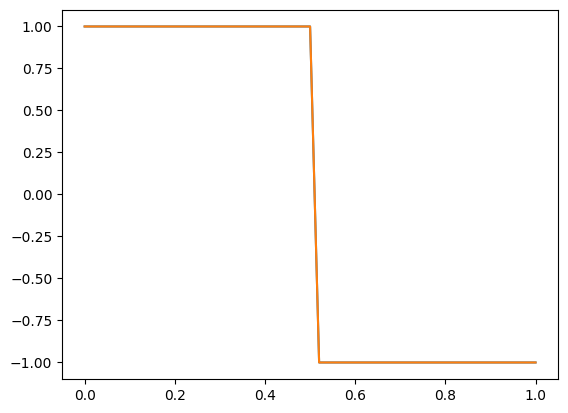

In [57]:
plt.plot(parameters, left_defect_op_invariants)
plt.plot(parameters, right_defect_op_invariants)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


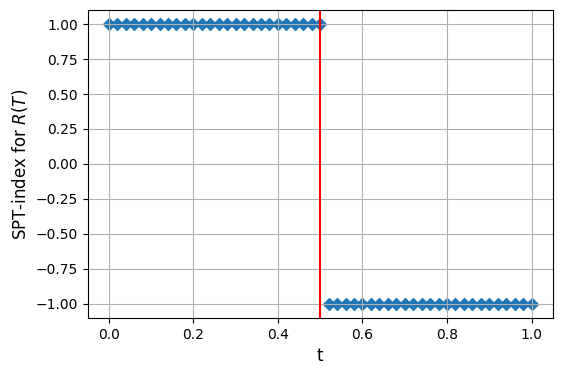

In [58]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(parameters, right_defect_op_invariants, marker='D')
ax.grid(zorder=-1)

ax.set_ylabel('SPT-index for $R(T)$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

ax.axvline(0.5, color='red')

fig.savefig(
    r'figures/purified_rho_spt_index.png',
    bbox_inches='tight',
    dpi=200
)

In [59]:
overlaps = np.array([
    l[3] for l in purification_rho_sweep_results
])

In [60]:
np.max(np.abs(np.imag(overlaps)))

0.0

In [61]:
overlaps = np.real(overlaps[:, -1])

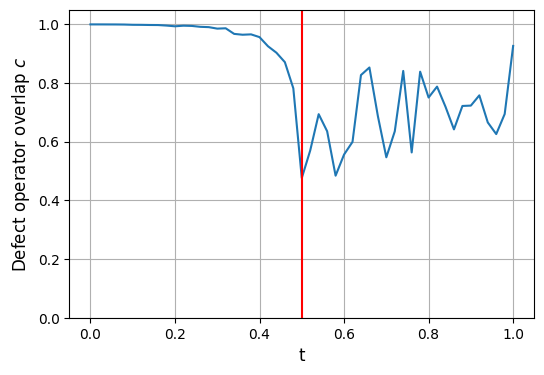

In [62]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(parameters, overlaps)
ax.grid(zorder=-1)

ax.set_ylabel('Defect operator overlap $c$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

ax.set_ylim(0,1.05)

ax.axvline(0.5, color='red')

fig.savefig(
    r'figures/purified_rho_defect_overlap.png',
    bbox_inches='tight',
    dpi=200
)

In [63]:
np.max(np.abs(np.array([l[4] for l in purification_rho_sweep_results])))

6.629855777565185e-20

So this method works, and appears to work well. But why?

### Purificaiton and defect operators on cut states

In [64]:
purification_diffs = [l[2] for l in sweep_results]

In [65]:
np.max(np.abs(np.array(purification_diffs)))

6.629855777565185e-20

In [66]:
purification_cut_state_sweep_results = [l[3] for l in sweep_results]

In [67]:
purification_cut_state_sweep_results[0][0]

[0.9999999999999992,
 array([1.]),
 (1.000000000000001+2.7755575615628914e-17j),
 (1.0000000000000004-5.551115123125783e-17j),
 [2.0267588258109703,
  1.0000000000000004,
  1.0000000000000009,
  1.0000000000000009,
  1.0000000000000004,
  1.0000000000000007,
  1.0000000000000013,
  1.0000000000000007,
  1.0000000000000009,
  1.000000000000001,
  1.0000000000000004,
  1.000000000000001,
  1.0000000000000007,
  1.0000000000000007,
  1.0000000000000004,
  1.0000000000000009,
  1.0000000000000004,
  1.0000000000000004,
  1.0000000000000013,
  1.0000000000000007,
  1.0000000000000009,
  1.0000000000000007,
  1.0000000000000007,
  1.0000000000000009,
  1.0000000000000007,
  1.0000000000000004,
  1.0000000000000009,
  1.000000000000001,
  1.0000000000000004,
  1.0000000000000009,
  1.0000000000000013,
  1.0000000000000009,
  1.0000000000000009,
  1.0000000000000007,
  1.0000000000000009,
  1.0000000000000009,
  1.000000000000001,
  1.0000000000000004,
  1.0000000000000009,
  1.000000000000000

Each list contains a list for each psi_i:
1. Singular value of psi_i extracted from rho.
2. Left right singular values of constructed edm $E_i$.
3. Left defect op invariant
4. Right Defect op invariant
5. Overlaps over iteration

In [68]:
plot_vert_schmidt_vals = list()
plot_lr_schmidt_vals = list()
plot_schmidt_val_indices = list()
plot_num_schmidt_vals = list()

plot_left_defect_invs = list()
plot_right_defect_invs = list()
plot_overlaps = list()

for i, l in enumerate(purification_cut_state_sweep_results):
    count=0
    for l1 in l:
        sh=l1[0]
        if sh > 0.05:
            plot_schmidt_val_indices.append(parameters[i])
            plot_vert_schmidt_vals.append(sh)
            plot_lr_schmidt_vals.append(l1[1])

            plot_left_defect_invs.append(l1[2])
            plot_right_defect_invs.append(l1[3])
            plot_overlaps.append(l1[4][-1])

            count+=1
    plot_num_schmidt_vals.append(count)

In [69]:
[np.round(l, 3) for l in plot_lr_schmidt_vals]

[array([1.]),
 array([1., 0., 0., 0., 0., 0., 0.]),
 array([1., 0., 0., 0., 0., 0., 0.]),
 array([1., 0., 0., 0., 0., 0., 0.]),
 array([0.999, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]),
 array([0.999, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ]),
 array([0.998, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ]),
 array([0.997, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   ]),
 array([0.996, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   ]),
 array([0.995, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   ]),
 array([0.993, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]),
 array([0.991, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]),
 array([0.988, 0.   , 0.   , 0.   , 0.   , 0.   , 

In [70]:
plot_num_schmidt_vals

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4]

Not sure how to plot this, but $E_i$ are long range entangled in the non-trivial SPT phase.

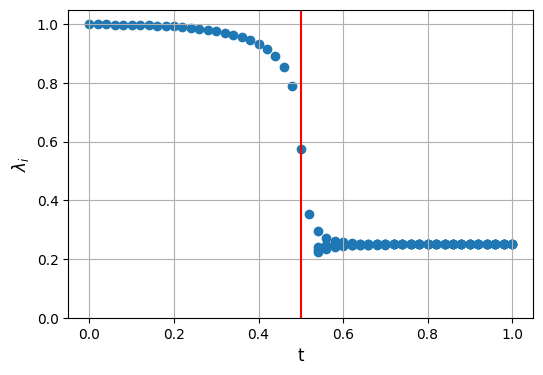

In [71]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(plot_schmidt_val_indices, plot_vert_schmidt_vals)
ax.grid(zorder=-1)

ax.set_ylabel('$\lambda_i$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

ax.set_ylim(0, 1.05)

ax.axvline(0.5, color='red')

fig.savefig(
    r'figures/purified_cut_states_vertical_rho_schmidt_vals.png',
    bbox_inches='tight',
    dpi=200
)

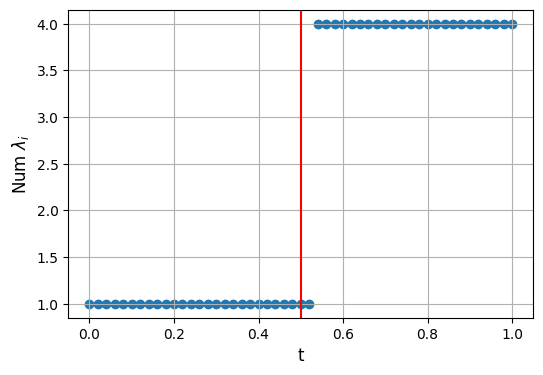

In [72]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(parameters, plot_num_schmidt_vals)
ax.grid(zorder=-1)

ax.set_ylabel('Num $\lambda_i$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

ax.axvline(0.5, color='red')

fig.savefig(
    r'figures/purified_cut_states_num_vertical_rho_schmidt_vals.png',
    bbox_inches='tight',
    dpi=200
)

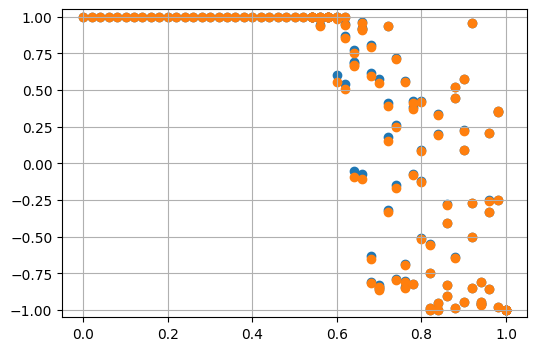

In [73]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(plot_schmidt_val_indices, plot_left_defect_invs)
ax.scatter(plot_schmidt_val_indices, plot_right_defect_invs)
ax.set_ylim(-1.05, 1.05)
ax.grid(zorder=-1)

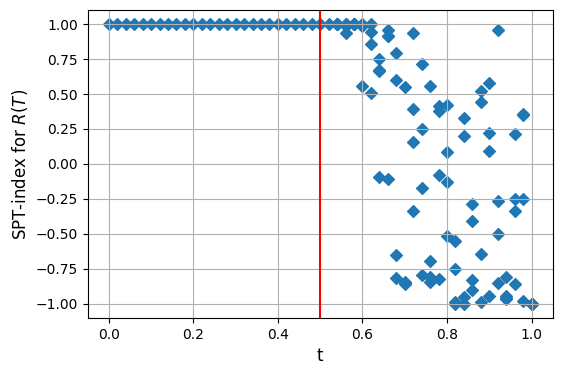

In [74]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(plot_schmidt_val_indices, plot_right_defect_invs, marker='D')
ax.grid(zorder=-1)

ax.set_ylabel('SPT-index for $R(T)$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

ax.axvline(0.5, color='red')

fig.savefig(
    r'figures/purified_cut_state_spt_index.png',
    bbox_inches='tight',
    dpi=200
)

So the invariants are breaking down in the nontrivial phase.

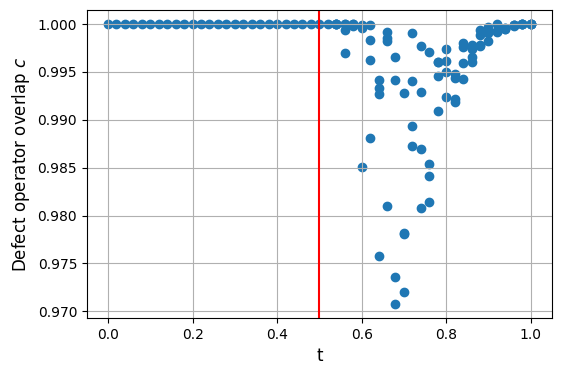

In [75]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(plot_schmidt_val_indices, plot_overlaps)
ax.grid(zorder=-1)

ax.set_ylabel('Defect operator overlap $c$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

#ax.set_ylim(0,1.05)

ax.axvline(0.5, color='red')

fig.savefig(
    r'figures/purified_cut_state_defect_overlap.png',
    bbox_inches='tight',
    dpi=200
)

So still finding good defect operators, but they are not giving us the invariant we expect...

### Tensor network factorizations

In [76]:
factorization_loss_curves = [l[4] for l in sweep_results]

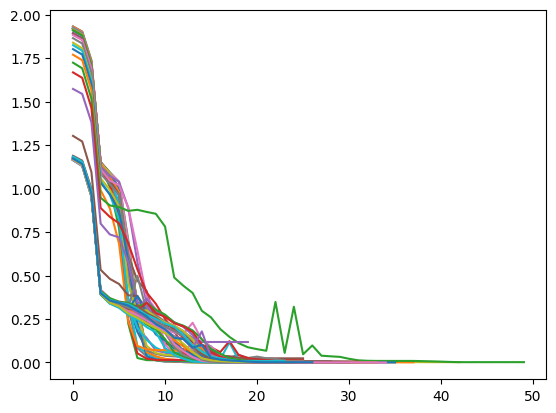

In [77]:
for l in factorization_loss_curves:
    plt.plot(l);

In [78]:
best_loss = [min(l) for l in factorization_loss_curves]

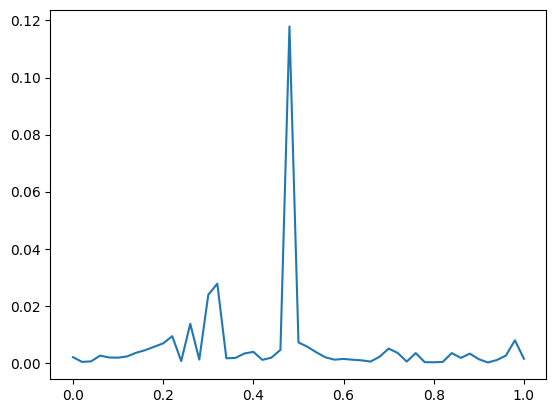

In [79]:
plt.plot(parameters, best_loss)

In [80]:
left_loss = [l[6] for l in sweep_results]
right_loss = [l[7] for l in sweep_results]

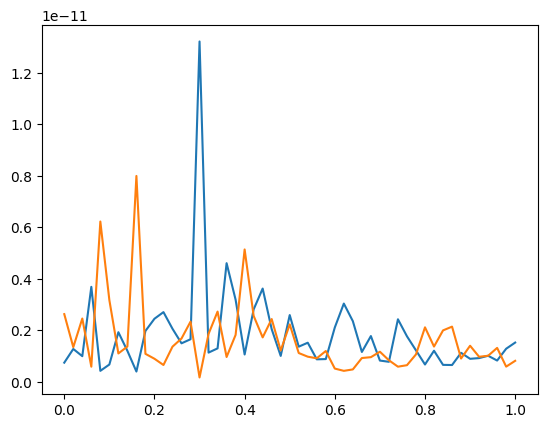

In [81]:
plt.plot(parameters, left_loss)
plt.plot(parameters, right_loss)

So the factorizations are pretty accurate.

### Factorized full effective density matrix

In [97]:
plot_schmidt_vals = list()
plot_schmidt_val_indices = list()
plot_num_schmidt_vals = list()

for i, l in enumerate(sweep_results):
    count=0
    for s in l[8]:
        if s > 0.05:
            plot_schmidt_val_indices.append(parameters[i])
            plot_schmidt_vals.append(s)

            count+=1
    plot_num_schmidt_vals.append(count)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


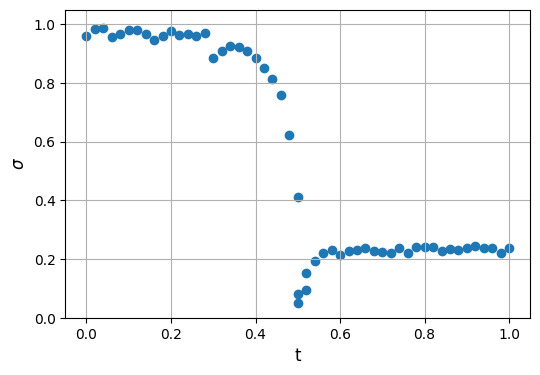

In [98]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(plot_schmidt_val_indices, plot_schmidt_vals)
ax.set_ylim(0, 1.05)
ax.grid(zorder=-1)

ax.set_ylabel('$\sigma$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

fig.savefig(
    r'figures/purified_factorized_rho_left_right_edm_schmidt_vals.png',
    bbox_inches='tight',
    dpi=200
)

In [99]:
plot_num_schmidt_vals

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

So these effective density matrices are short range entangled!

In [100]:
left_invariants = [l[9] for l in sweep_results]
right_invariants = [l[10] for l in sweep_results]

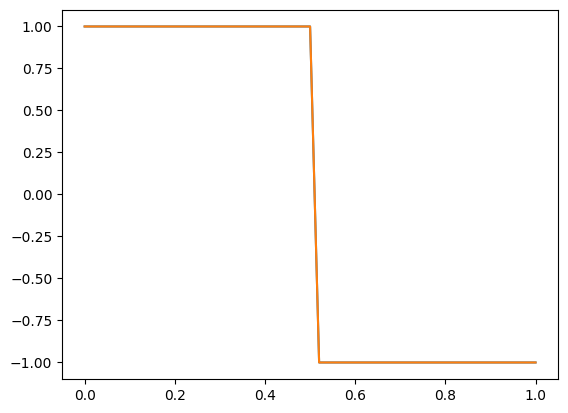

In [101]:
plt.plot(parameters, left_invariants)
plt.plot(parameters, right_invariants)

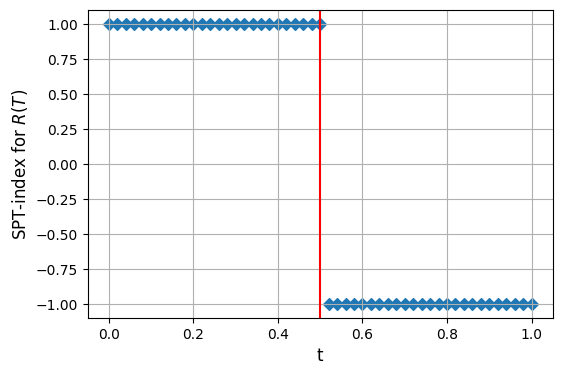

In [102]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(parameters, right_invariants, marker='D')
ax.grid(zorder=-1)

ax.set_ylabel('SPT-index for $R(T)$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

ax.axvline(0.5, color='red')

fig.savefig(
    r'figures/purified_factorized_rho_spt_index.png',
    bbox_inches='tight',
    dpi=200
)

In [103]:
overlaps = [l[11][-1] for l in sweep_results]

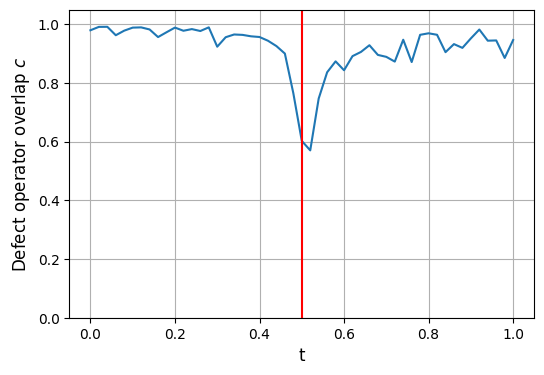

In [104]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(parameters, overlaps)
ax.grid(zorder=-1)

ax.set_ylabel('Defect operator overlap $c$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

ax.set_ylim(0,1.05)

ax.axvline(0.5, color='red')

fig.savefig(
    r'figures/purified_factorized_rho_defect_overlap.png',
    bbox_inches='tight',
    dpi=200
)

So this is all working out as expected. $E$ is short range entangled, defect operators are succesfully extracted. Overlap scores are better in nontrivial case than in non-factorized case.

### Factorized cut states

In [105]:
factorized_cut_state_sweep_results = [l[12] for l in sweep_results]

In [106]:
factorized_cut_state_sweep_results[0][0]

[0.67538404,
 1.4443876,
 array([9.99991372e-01, 2.10243437e-04, 2.10048446e-04, 7.15505159e-05,
        7.14727230e-05, 1.02891728e-05, 1.02589452e-05, 1.21517722e-07,
        7.81095668e-08, 5.24248492e-08, 4.21953810e-08, 3.49418174e-08,
        2.34249335e-08, 1.91448556e-08, 8.72170466e-09, 8.67788612e-09]),
 (0.9999998658895505+1.457167719820518e-16j),
 (0.9999999850988391+3.8562569804057034e-10j),
 0.999998064522976]

In [107]:
plot_left_vert_schmidt_vals = list()
plot_right_vert_schmidt_vals = list()
plot_lr_schmidt_vals = list()
plot_schmidt_val_indices = list()
plot_num_schmidt_vals = list()

plot_left_defect_invs = list()
plot_right_defect_invs = list()
plot_overlaps = list()

for i, l in enumerate(factorized_cut_state_sweep_results):
    count=0
    for l1 in l:
        sl=l1[0]
        sr=l1[1]
        if (sl > 0.2) & (sr > 0.2) :
            plot_schmidt_val_indices.append(parameters[i])
            plot_left_vert_schmidt_vals.append(sl)
            plot_right_vert_schmidt_vals.append(sr)
            plot_lr_schmidt_vals.append(l1[2])

            plot_left_defect_invs.append(l1[3])
            plot_right_defect_invs.append(l1[4])
            plot_overlaps.append(l1[5])

            count+=1
    plot_num_schmidt_vals.append(count)

In [108]:
[np.round(l, 3) for l in plot_lr_schmidt_vals]

[array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([1.   , 0.001, 0.001, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]),
 array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0.999, 0.002, 0.002, 0.001, 0.001, 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]),
 array([0.999, 0.002, 0.001, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]),
 array([0.999, 0.001, 0.001, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]),
 array([0.998, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]),
 array([0.997, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ]),
 array([0.996, 0.003, 0.003, 0.001, 0.001, 0.   , 0.   , 0.   , 0.   ,
 

Well approximated as short range entangled.

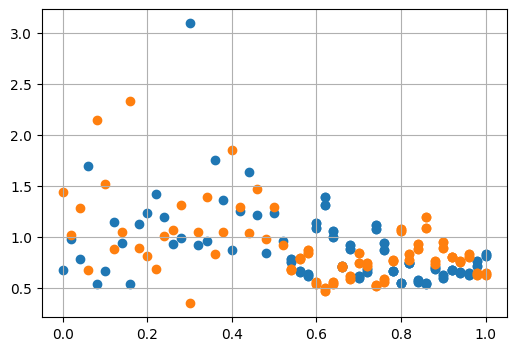

In [93]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(plot_schmidt_val_indices, plot_left_vert_schmidt_vals)
ax.scatter(plot_schmidt_val_indices, plot_right_vert_schmidt_vals)
#ax.set_ylim(-0.05, 1.05)
ax.grid(zorder=-1)

Left and right schmidt values have different magnitudes, should normalize the left and right tensors to have the same magnitude.

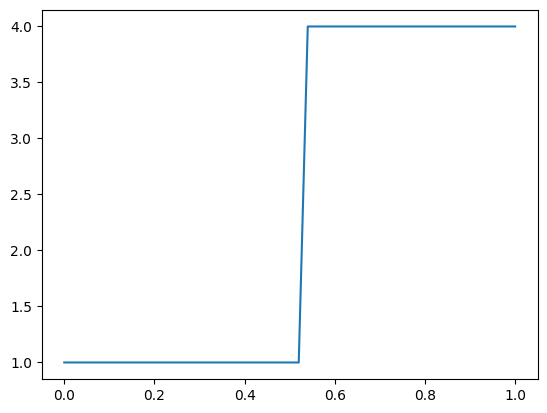

In [94]:
plt.plot(parameters, plot_num_schmidt_vals)

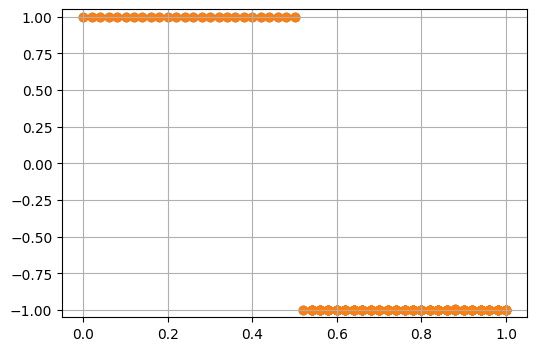

In [95]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(plot_schmidt_val_indices, plot_left_defect_invs)
ax.scatter(plot_schmidt_val_indices, plot_right_defect_invs)
ax.set_ylim(-1.05, 1.05)
ax.grid(zorder=-1)

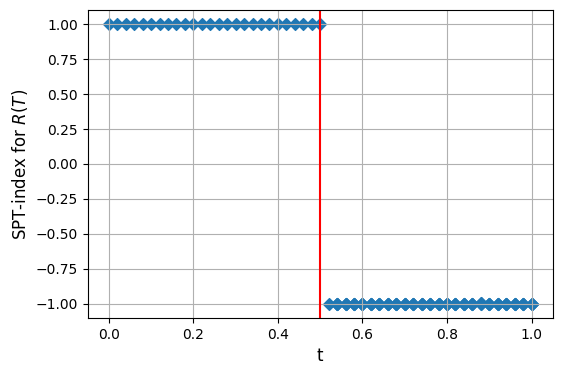

In [111]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(plot_schmidt_val_indices, plot_right_defect_invs, marker='D')
ax.grid(zorder=-1)

ax.set_ylabel('SPT-index for $R(T)$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

ax.axvline(0.5, color='red')

fig.savefig(
    r'figures/purified_factorized_rho_cut_state_spt_index.png',
    bbox_inches='tight',
    dpi=200
)

Clean invariants.

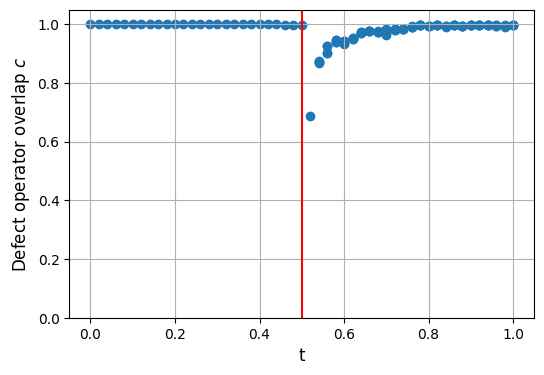

In [112]:
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(plot_schmidt_val_indices, plot_overlaps)
ax.grid(zorder=-1)

ax.set_ylabel('Defect operator overlap $c$', fontsize=12)
ax.set_xlabel('t', fontsize=12)

ax.set_ylim(0,1.05)

ax.axvline(0.5, color='red')

fig.savefig(
    r'figures/purified_factorized_rho_cut_state_spt_overlap.png',
    bbox_inches='tight',
    dpi=200
)

Good overlaps.

# Conclusions
More or less aligns with expectations, but still questions of what's going on.
Just run on more states now.